In [3]:
%pip install keras tensorflow


Defaulting to user installation because normal site-packages is not writeable
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached tensorflow-2.21.0-cp313-cp313-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.20.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (32 kB)
  Using cached ml_dtypes-0.6.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6

In [1]:
import keras 
from keras.datasets import mnist 
from keras.models import Sequential 
from keras.layers import Dense 
from tensorflow.keras.optimizers import SGD 
from matplotlib import pyplot as plt

I0000 00:00:1790670253.507702    6128 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790670253.509556    6128 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790670253.777150    6128 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790670254.712261    6128 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
(x_train,y_train),(x_valid,y_valid) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
y_train.shape

(60000,)

In [5]:
y_train[0:12]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5], dtype=uint8)

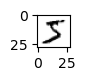

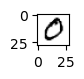

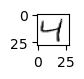

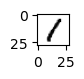

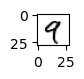

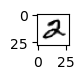

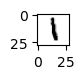

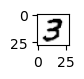

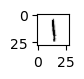

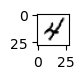

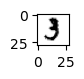

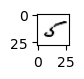

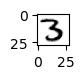

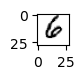

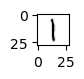

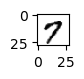

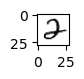

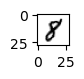

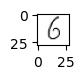

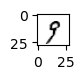

In [6]:
plt.figure(figsize=(5,5))
for k in range(20):
    plt.subplot(10,2,k+1) 
    plt.imshow(x_train[k],cmap='Greys')
    plt.axis('on')
    plt.show()

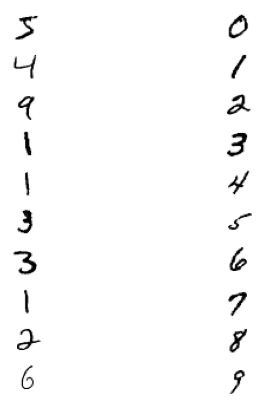

In [7]:
plt.figure(figsize=(5,5))
for k in range(20):
    plt.subplot(10,2,k+1)
    plt.imshow(x_train[k],cmap='Greys') 
    plt.axis('off')
plt.show()

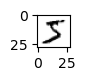

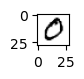

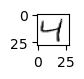

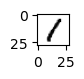

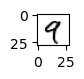

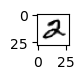

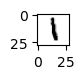

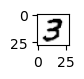

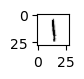

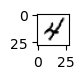

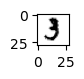

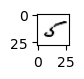

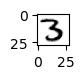

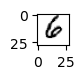

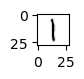

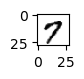

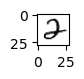

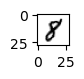

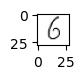

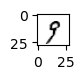

In [8]:
plt.figure(figsize=(5,5))
for k in range(20): 
    plt.subplot(10,2,k+1)
    plt.imshow(x_train[k],cmap='Greys') 
    plt.axis('on')
    plt.show()

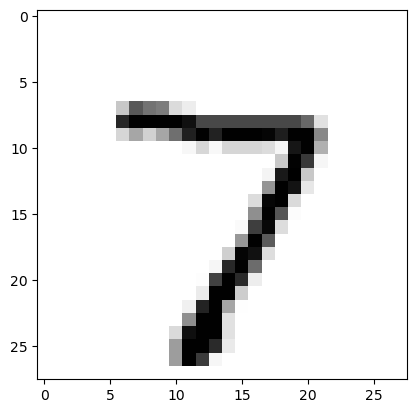

In [9]:
plt.imshow(x_valid[0],cmap='Greys')

In [10]:
y_valid.shape

(10000,)

In [11]:
x_valid[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [12]:
y_valid[0]

np.uint8(7)

In [14]:
x_train = x_train.reshape(60000,784).astype('float32')
x_valid = x_valid.reshape(10000,784).astype('float32')

In [15]:
x_train/=255 
x_valid/=255

In [17]:
from keras import utils as np_utils

n_classes = 10

y_train = np_utils.to_categorical(y_train, n_classes)
y_valid = np_utils.to_categorical(y_valid, n_classes)


In [18]:
y_valid[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [19]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [20]:
x_valid[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [21]:
x_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [22]:
y_valid[3]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [25]:
from keras import Sequential
from keras.layers import Input, Dense

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(64, activation='sigmoid'))


In [26]:
model.add(Dense(10, activation='softmax'))

In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
(64*784) 

50176

In [29]:
(64*784)+64

50240

In [30]:
(10*64)

640

In [31]:
(10*64)+10

650

In [32]:
((10*64)+10) +((64*784)+64)

50890

In [34]:
model.compile(loss='mean_squared_error',optimizer=SGD(learning_rate=0.03),metrics=['accuracy'])

In [35]:
history= model.fit(x_train,y_train,batch_size=128,epochs=75,verbose=1)

Epoch 1/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1191 - loss: 0.0917
Epoch 2/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1474 - loss: 0.0898
Epoch 3/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2048 - loss: 0.0888  
Epoch 4/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2961 - loss: 0.0878
Epoch 5/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3945 - loss: 0.0868
Epoch 6/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4598 - loss: 0.0859  
Epoch 7/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4810 - loss: 0.0848
Epoch 8/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.4865 - loss: 0.0838
Epoch 9/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4875 - loss: 0.0826  
Epoch 10/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4927 - loss: 0.0813
Epoch 11/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step - accuracy: 0.4962 - loss: 0.0800
Epoch 12/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0

Text(0, 0.5, 'epoch')

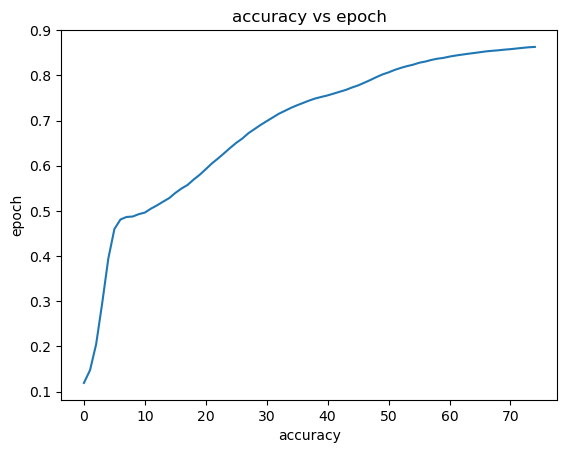

In [37]:
plt.plot(history.history['accuracy'])
plt.title('accuracy vs epoch')
plt.xlabel('accuracy') 
plt.ylabel('epoch')


Text(0, 0.5, 'epoch')

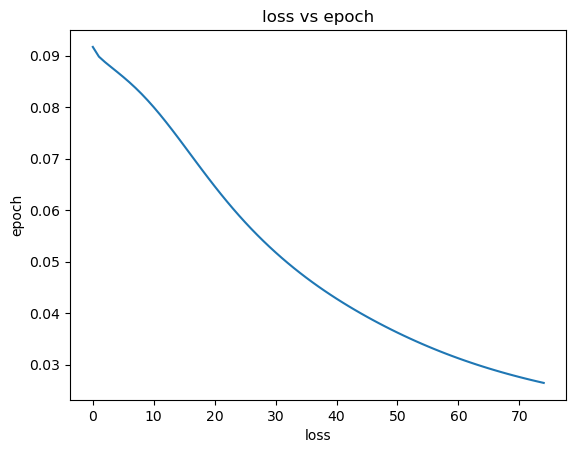

In [38]:
plt.plot(history.history['loss']) 
plt.title('loss vs epoch')
plt.xlabel('loss') 
plt.ylabel('epoch')